In [1]:
import datajoint as dj
dj.config.load('C:\\Secrets\\dj_local_conf.json')
dj.conn() 
direction_dict = {'LR':'Left - Right',
                  'RL':'Right - Left',
                  'AP':'Anterior - Posterior',
                  'PA':'Posterior - Anterior'}
#%% import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
from ndnf_pipeline import lab, experiment
import numpy as np
# connect to the database

c:\Scripts\NDNF-pipeline\.venv\Lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-05-29 16:01:58,629][INFO]: DataJoint is configured from C:\Secrets\dj_local_conf.json
[2026-05-29 16:01:58,679][INFO]: DataJoint 0.14.6 connected to rozmar@datajoint.ndnf.koki.hun-ren.hu:3306


Text(0, 0.5, 'Number of Trials')

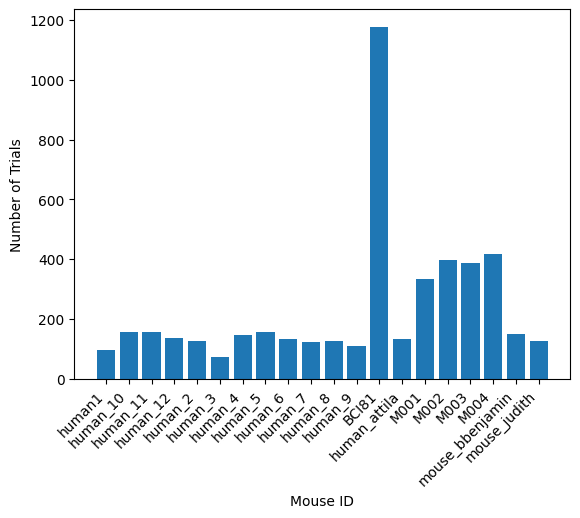

In [9]:
from ndnf_pipeline import lab

# find the mouse IDs that have been used in the experiment and count the number of trials for each mouse, then plot a bar graph
mouse_IDs = lab.Subject.fetch('subject_id')
trial_nums = []
for m in mouse_IDs:
    trial_nums.append(len((experiment.SessionTrial()&{'subject_id':m})))
trial_nums = np.array(trial_nums)
needed_mice = trial_nums>0

fig = plt. figure()
plt.bar(mouse_IDs[needed_mice], trial_nums[needed_mice])
plt.xticks(rotation=45, ha="right")
plt.xlabel('Mouse ID')
plt.ylabel('Number of Trials')


In [ ]:
# order the subject IDs based on the number at the end of the ID, and ignore those that do not have a number at the end of the ID
subject_ids_ordered = []
subject_id_indices = []
include_benjamin = False

for subject_id in mouse_IDs[needed_mice]:
    if 'human' not in subject_id:
        if 'bbenjamin' in subject_id and include_benjamin:
            subject_id_indices.append(-1)
            subject_ids_ordered.append(subject_id)
            continue
        else:
            continue
    if '_' not in subject_id:
        subject_id_indices.append(int(subject_id[-1]))
    else:
        try:
            subject_id_indices.append(int(subject_id.split('_')[-1]))
        except:
            subject_id_indices.append(None)
    subject_ids_ordered.append(subject_id)
subject_id_indices = np.array(subject_id_indices)
subject_ids_ordered = np.array(subject_ids_ordered)
needed = subject_id_indices !=None
subject_id_indices = subject_id_indices[needed]
subject_ids_ordered = subject_ids_ordered[needed]
subject_ids_ordered = subject_ids_ordered[np.argsort(subject_id_indices)]
subject_id_indices = subject_id_indices[np.argsort(subject_id_indices)]

In [17]:
subject_ids_ordered

array(['human1', 'human_2', 'human_3', 'human_4', 'human_5', 'human_6',
       'human_7', 'human_8', 'human_9', 'human_10', 'human_11',
       'human_12'], dtype='<U12')

C:\Users\labadmin\AppData\Local\Temp\ipykernel_84472\333734385.py:73: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_84472\333734385.py:73: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_84472\333734385.py:73: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_84472\333734385.py:73: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_84472\333734385.py:73: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_84472\333734385.py:73: RuntimeWarning: divide by zero encountered in

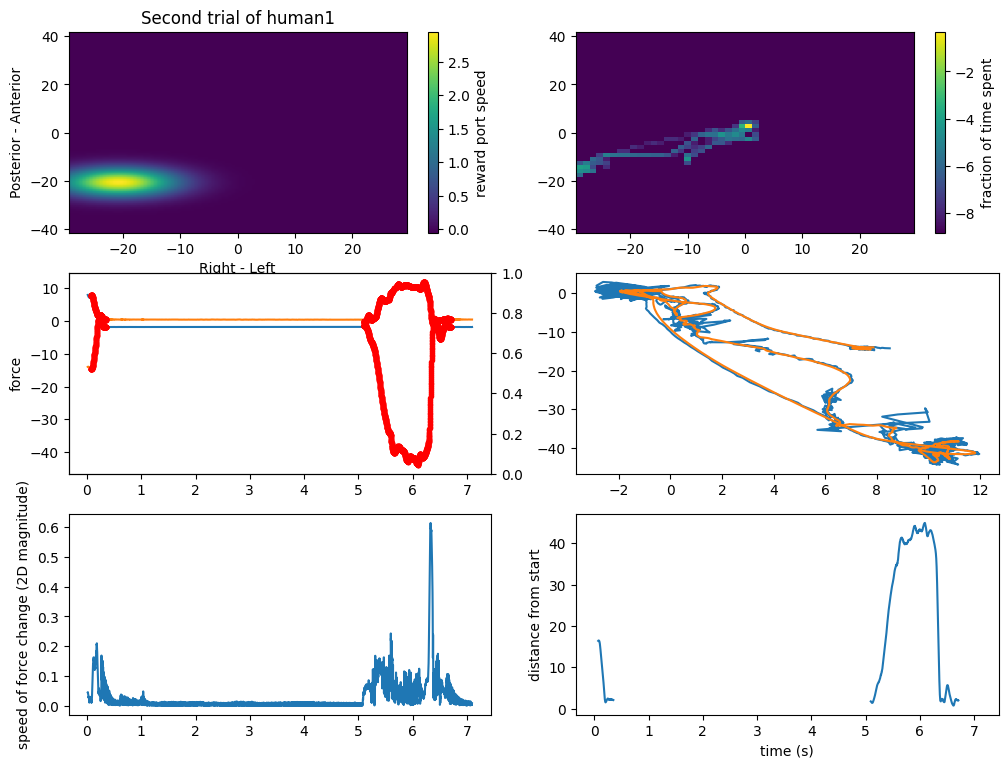

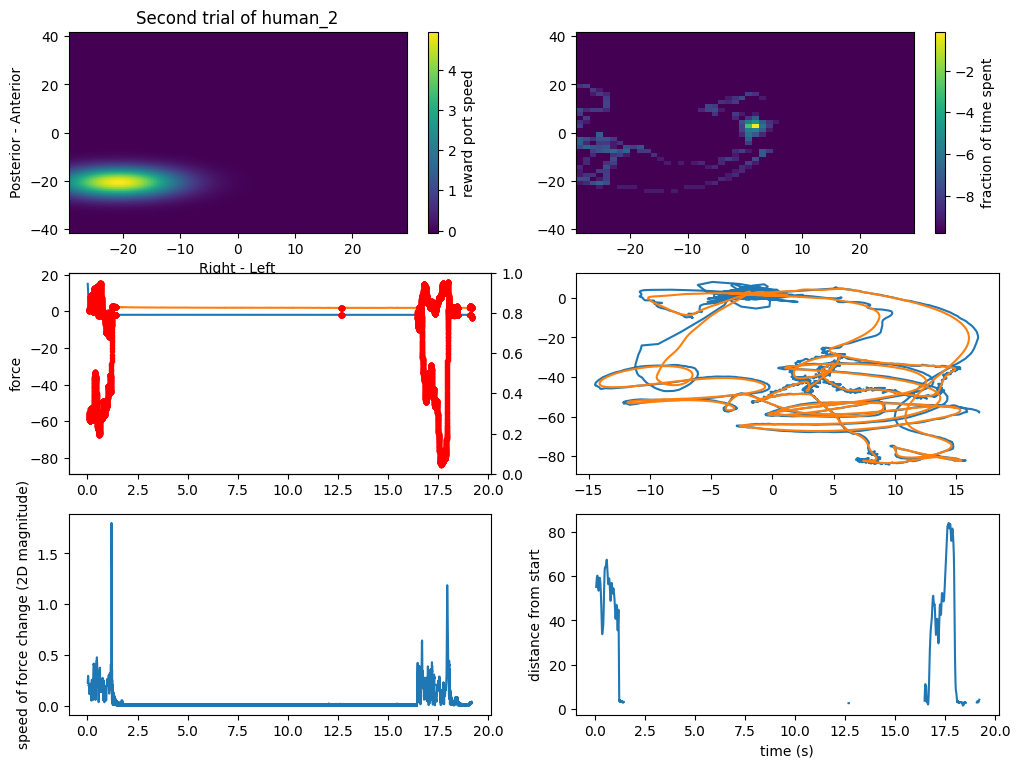

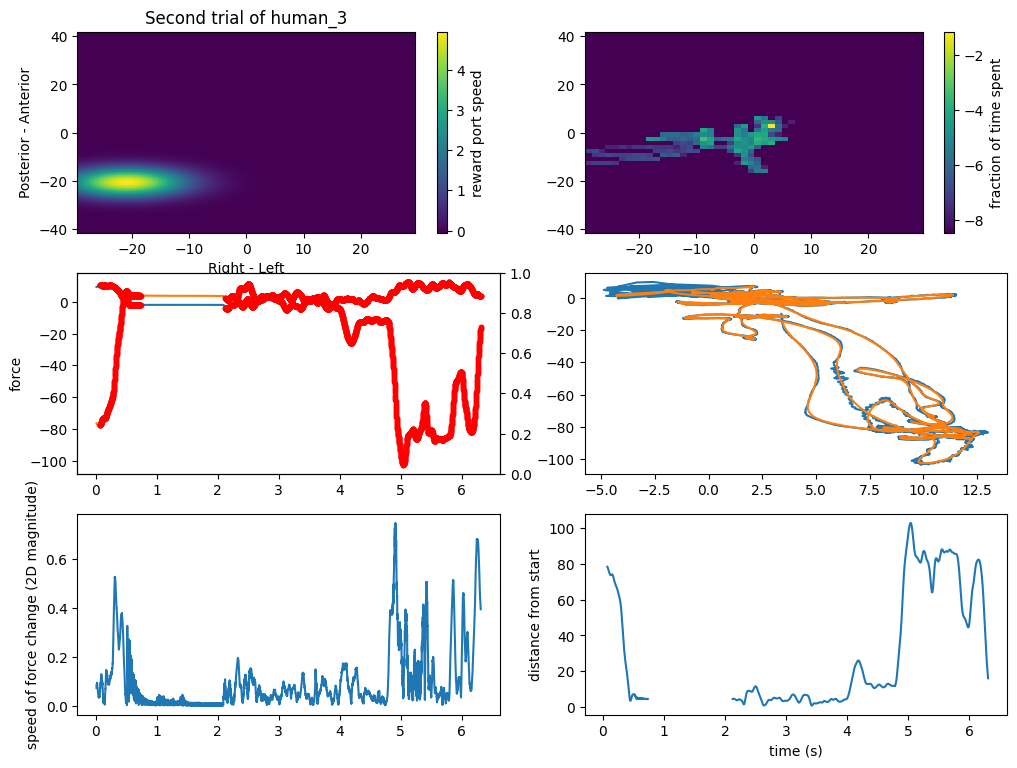

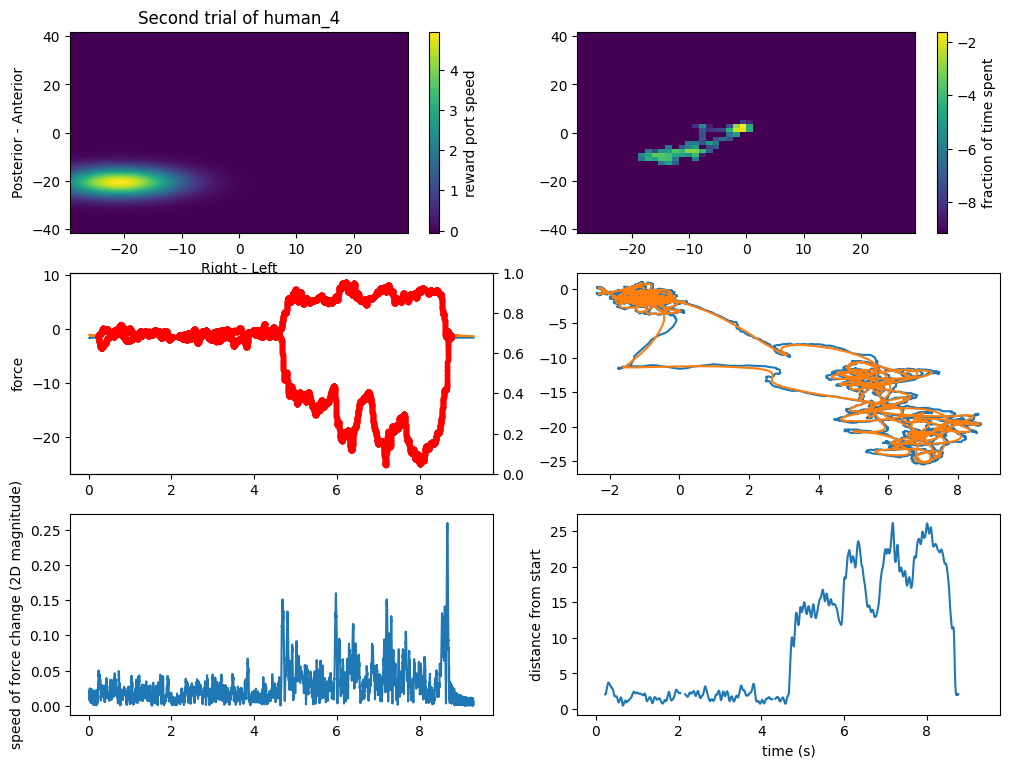

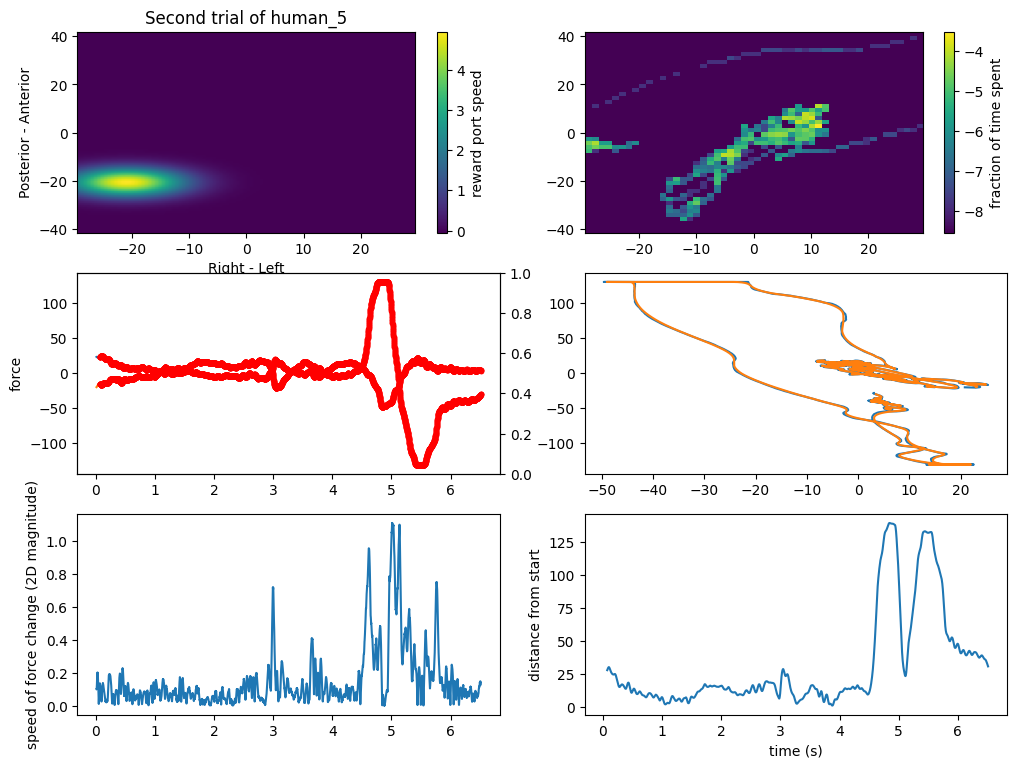

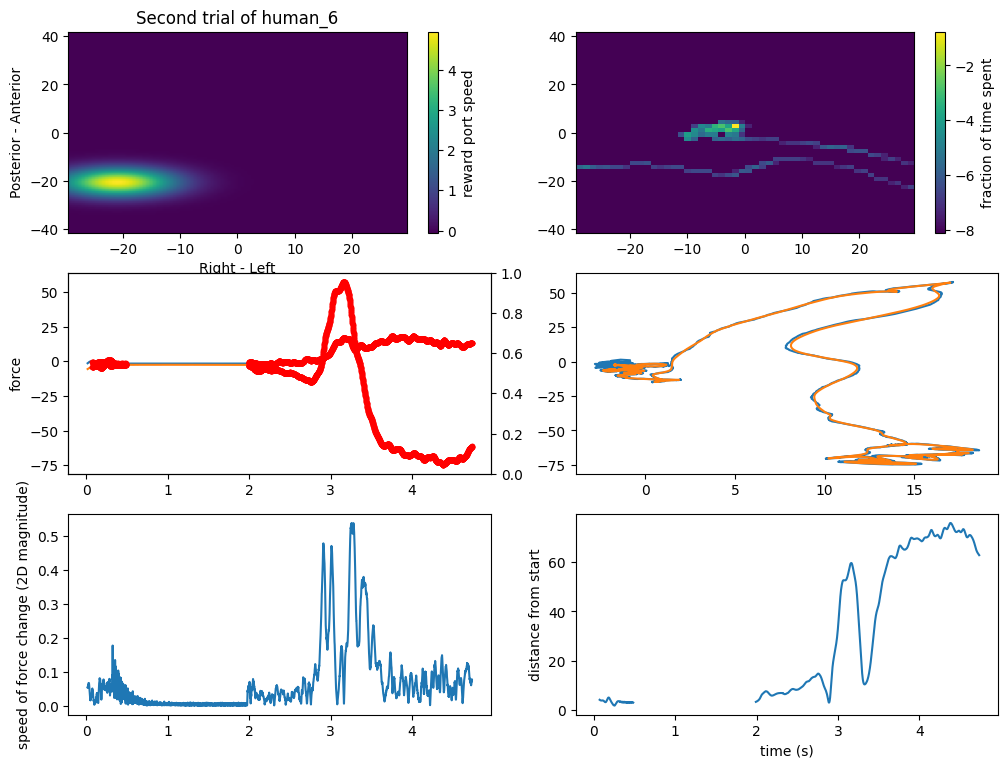

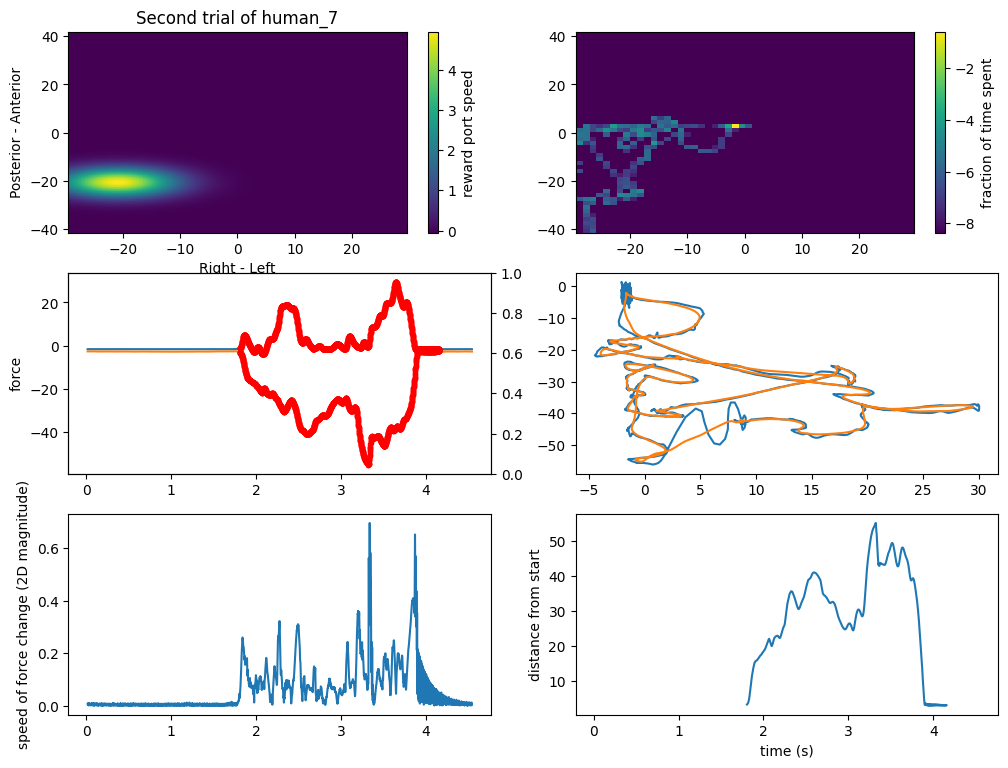

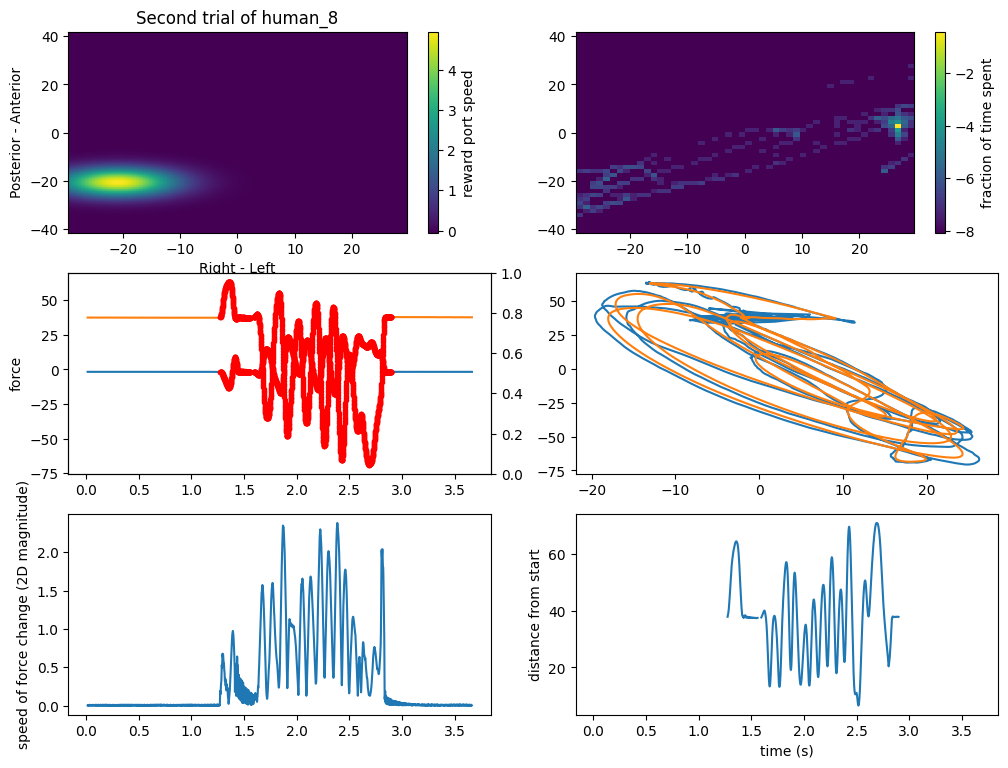

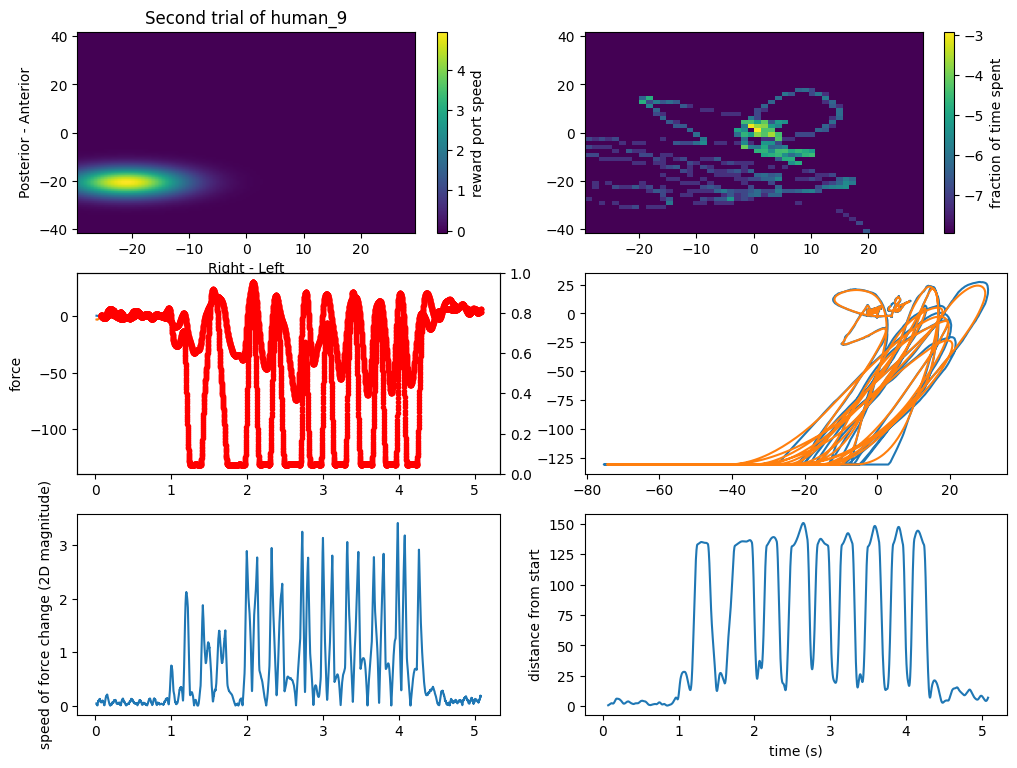

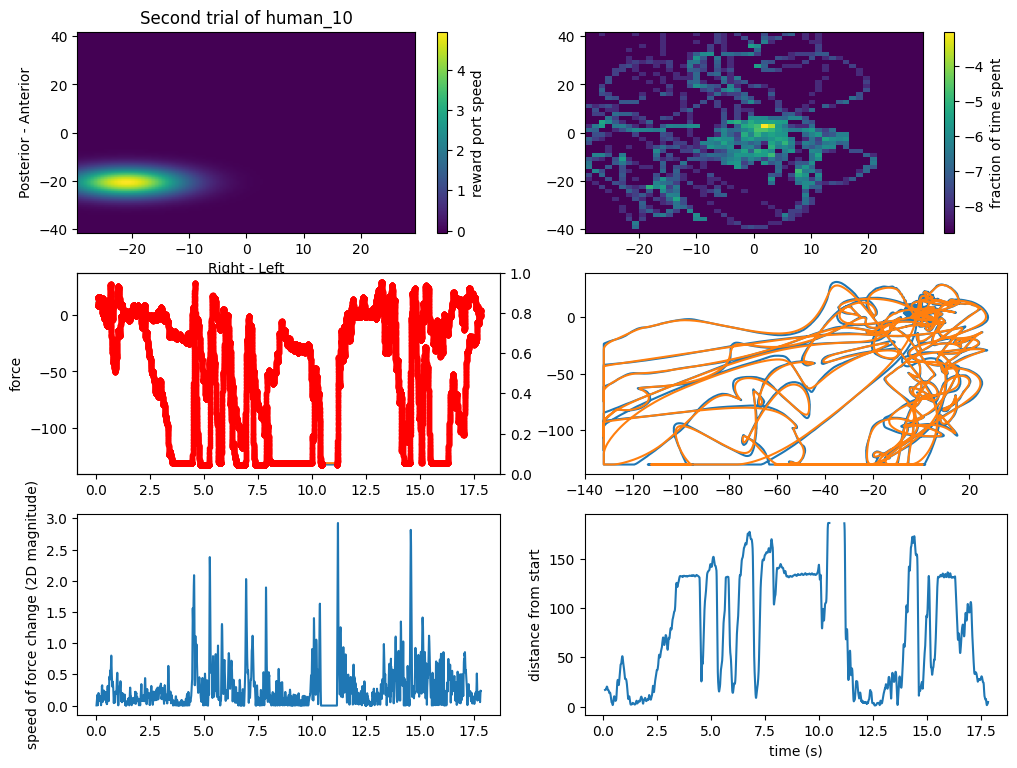

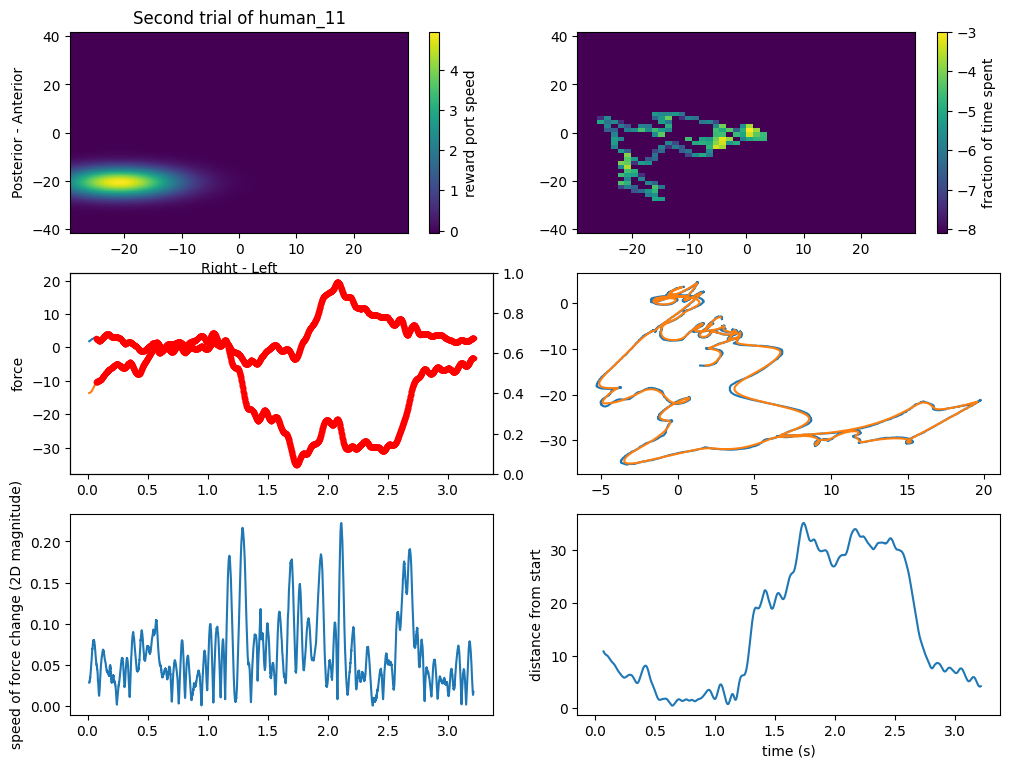

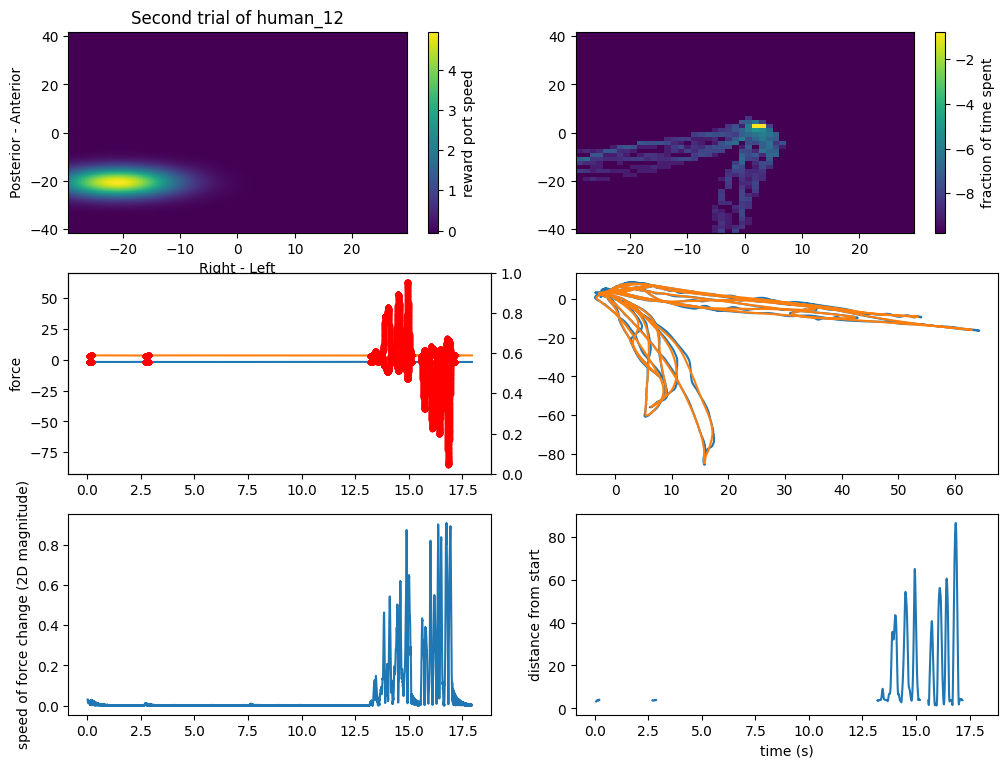

In [20]:
import matplotlib.pyplot as plt
import numpy as np
subtract_force_median = False
force_uniform_range = False
uniform_force_range= np.asarray([-1,1,-1,1])*100
subtract_median = False

for subject_id in subject_ids_ordered:
    available_sessions = (experiment.Session()&{'subject_id':subject_id}).fetch('session')
    if 0 not in available_sessions:
        print(f'{subject_id} does not have session 0')
        continue
    # visualize targets, and how forces change over sessions and trials
    session = 0

    task_setting_ids,target_force_luts = (experiment.TaskSettings()&{'subject_id':subject_id,'session':session}).fetch('task_setting_id','target_force_lut')
    force_axes = (experiment.TaskSettings.ForceAxis()&{'subject_id':subject_id,'session':session}).fetch(as_dict=True)
    task_setting_id = task_setting_ids[0]
    target_force_lut = target_force_luts[0]

    fig = plt.figure(figsize=(12,12))
    ax_target_LUT = fig.add_subplot(4,2,1)
    force_axes_dict = {}
    for fa in force_axes:
        if fa['task_setting_id'] == task_setting_id:
            force_axes_dict[fa['force_axis_idx']] = {'force_direction':fa['force_direction'],
                                                'target_force_axes':fa['target_force_axes']}
    if force_uniform_range:
        im0 = plt.imshow(np.ones(target_force_lut.shape)*np.min(target_force_lut.flatten()),extent = uniform_force_range,alpha = 1)                                            
    im_lut = plt.imshow(target_force_lut,extent = [force_axes_dict[0]['target_force_axes'][0],force_axes_dict[0]['target_force_axes'][-1],
                                                force_axes_dict[1]['target_force_axes'][0],force_axes_dict[1]['target_force_axes'][-1]],
                                                origin='upper',
                                                cmap='viridis',
                                                aspect='auto')
    plt.xlabel(direction_dict[force_axes_dict[0]['force_direction']])
    plt.ylabel(direction_dict[force_axes_dict[1]['force_direction']])
    plt.colorbar(im_lut,label='reward port speed')
    plt.title('Second trial of {}'.format(subject_id))

    
    if force_uniform_range:
        ax_target_LUT.set_xlim([uniform_force_range[0],uniform_force_range[1]])
        ax_target_LUT.set_ylim([uniform_force_range[2],uniform_force_range[3]])



    ax_force_hist = fig.add_subplot(4,2,2)
    force_traces_0 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings()&{'subject_id':subject_id,'session':session,'force_axis_idx':0,'task_setting_id':task_setting_id, 'trial':1}).fetch1('force_trace_value')
    force_traces_1 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':1,'task_setting_id':task_setting_id, 'trial':1}).fetch1('force_trace_value')
    force_traces_2 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':2,'task_setting_id':task_setting_id, 'trial':1}).fetch1('force_trace_value')
    if subtract_median:
        force_traces_0 = force_traces_0 - np.median(force_traces_0)
        force_traces_1 = force_traces_1 - np.median(force_traces_1)
        force_traces_2 = force_traces_2 - np.median(force_traces_2)
    force_trace_time = (experiment.TrialForceTrace()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'task_setting_id':task_setting_id, 'trial':1}).fetch('force_trace_time')
    reward_port_time, reward_port_position = (experiment.TrialRewardPortPosition*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'task_setting_id':task_setting_id, 'trial':1}).fetch('reward_port_position_time','reward_port_position_values')


    if force_uniform_range:
        histrange = [uniform_force_range[:2],uniform_force_range[:2]]
    else:
        histrange = [[force_axes_dict[0]['target_force_axes'][0],
                    force_axes_dict[0]['target_force_axes'][-1]],
                    [force_axes_dict[1]['target_force_axes'][0],
                    force_axes_dict[1]['target_force_axes'][-1]]]
    
    try:
        forcehist,binx,biny = np.histogram2d(force_traces_0,
                                            force_traces_1,
                                            range=histrange,
                                            bins=50)
        forcehist_all = forcehist.copy()
        forcehist = np.log(forcehist/sum(forcehist.flatten()))
        forcehist_ = forcehist.copy()
        forcehist_ [np.isinf(forcehist )] = 0
        forcehist[np.isinf(forcehist)] = np.nanmin(forcehist_.flatten())
        im_hist = ax_force_hist.imshow(forcehist,
                                    extent = [binx[0],binx[-1],biny[0],biny[-1]],
                                        alpha = 1,
                                        aspect= 'auto')
        plt.colorbar(im_hist,label = 'fraction of time spent')
    except:
        pass



    smooth_window = 30
    sd_window = 60
    threshold_distance_for_hold = 40

    ax1 = fig.add_subplot(4,2,3)
    ax1_position = ax1.twinx()
    ax2 = fig.add_subplot(4,2,4)
    ax3 = fig.add_subplot(4,2,5,sharex=ax1)
    ax_sd = fig.add_subplot(4,2,6,sharex=ax1)



    force_trace_0_smooth = np.convolve(force_traces_0,np.ones(smooth_window)/smooth_window,mode='valid')
    force_trace_1_smooth = np.convolve(force_traces_1,np.ones(smooth_window)/smooth_window,mode='valid')
    force_trace_0_sd =  pd.Series(force_trace_0_smooth).rolling(window=sd_window).std()
    force_trace_1_sd =  pd.Series(force_trace_1_smooth).rolling(window=sd_window).std()


    #holding_times = distance_from_start_smooth>threshold_distance_for_hold



    force_time = np.arange(len(force_traces_0))*np.median(np.diff(np.concatenate(force_trace_time)))
    force_time_smooth = np.convolve(force_time,np.ones(smooth_window)/smooth_window,mode='valid')

    distance_from_start = np.sqrt(force_traces_0**2 + force_traces_1**2)
    distance_from_start_smooth = np.convolve(distance_from_start,np.ones(smooth_window)/smooth_window,mode='valid')

    holding_times = distance_from_start_smooth>threshold_distance_for_hold

    force_magnitude_smooth = np.sqrt(force_trace_0_smooth**2 + force_trace_1_smooth**2)
    force_magnitude_smooth_sd = pd.Series(force_magnitude_smooth).rolling(window=sd_window).std()
    contact_times = force_magnitude_smooth_sd>.05#np.percentile(force_magnitude_smooth_sd,5)

    force_angle_smooth = np.degrees(np.arctan2(force_trace_1_smooth, force_trace_0_smooth)) 


    ax1.plot(force_time_smooth,force_trace_0_smooth,label=direction_dict[force_axes_dict[0]['force_direction']])
    ax1.plot(force_time_smooth,force_trace_1_smooth,label=direction_dict[force_axes_dict[1]['force_direction']])
    ax1.plot(force_time_smooth[contact_times],force_trace_0_smooth[contact_times],'r.',label=direction_dict[force_axes_dict[0]['force_direction']])
    ax1.plot(force_time_smooth[contact_times],force_trace_1_smooth[contact_times],'r.',label=direction_dict[force_axes_dict[1]['force_direction']])
    
    ax1.set_ylabel('force')

    ax2.plot(force_traces_0,force_traces_1)
    ax2.plot(force_trace_0_smooth,force_trace_1_smooth)
    #ax2.plot(force_trace_0_smooth[holding_times],force_trace_1_smooth[holding_times],'r.')


    d0 = np.diff(force_trace_0_smooth)
    d1 = np.diff(force_trace_1_smooth)
    speed_2d = np.sqrt(d0**2 + d1**2)

    ax3.plot(force_time_smooth[:-1], speed_2d, label='2D force speed')
    ax3.set_ylabel('speed of force change (2D magnitude)')


    mean_sd = np.mean([force_trace_0_sd,force_trace_1_sd],axis=0)


    distance_from_start_smooth[contact_times==False] = np.nan
    ax_sd.plot(force_time_smooth,distance_from_start_smooth,label='distance')
    #ax_sd.plot(force_time_smooth[holding_times],distance_from_start_smooth[holding_times],color = 'red',label='holding times')
    ax_sd.set_xlabel('time (s)')
    ax_sd.set_ylabel('distance from start')

    #break


    
    

In [28]:
sum(contact_times)

3777

''

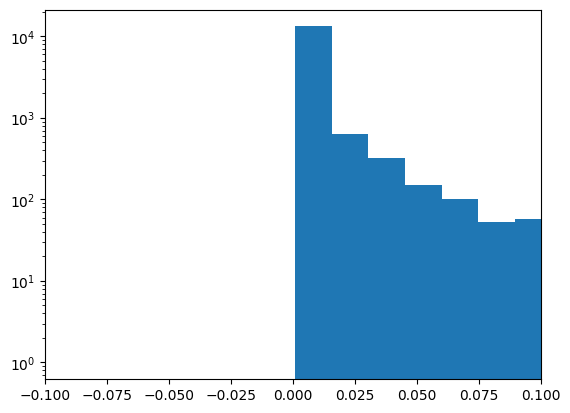

In [27]:
#plt.plot(force_magnitude_smooth)
plt.hist(force_magnitude_smooth_sd,1000)
plt.yscale('log')
plt.xlim([-.1,.1])
''

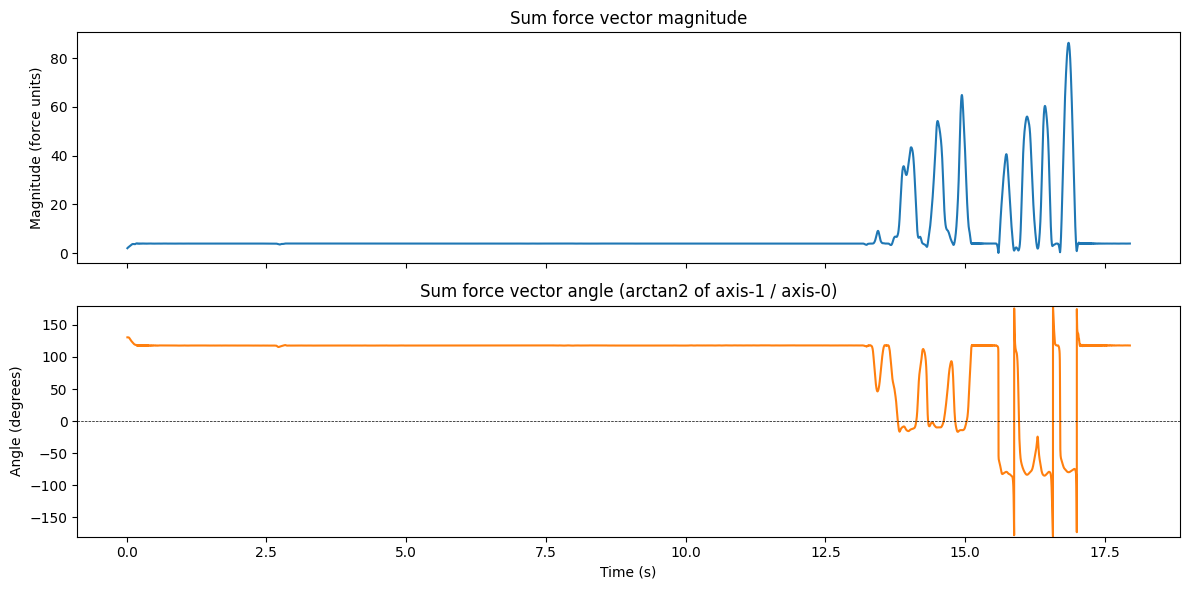

In [23]:
# Sum force vector: magnitude and angle from the two smoothed 2D components
force_magnitude_smooth = np.sqrt(force_trace_0_smooth**2 + force_trace_1_smooth**2)
force_angle_smooth = np.degrees(np.arctan2(force_trace_1_smooth, force_trace_0_smooth))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(force_time_smooth, force_magnitude_smooth, color='tab:blue')
axes[0].set_ylabel('Magnitude (force units)')
axes[0].set_title('Sum force vector magnitude')

axes[1].plot(force_time_smooth, force_angle_smooth, color='tab:orange')
axes[1].set_ylabel('Angle (degrees)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Sum force vector angle (arctan2 of axis-1 / axis-0)')
axes[1].set_ylim(-180, 180)
axes[1].axhline(0, color='k', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()